# AI-Powered Stock Decision System using Deep Learning and Real-Time News Sentiment Analysis


Stock : Saudi Aramco 2222

Data : Yahoo Finance (yfinance - auto downloaded historical data)

News : Google News RSS (Web Scraping)

Model : LSTM Neural Network (Time Series Forecasting)

NLP : FinBERT (Financial Sentiment Analysis)

Features:  Historical Price Data (Open, High, Low, Close, Volume) + News Sentiment Scores (Time-Weighted)


Output : BUY / SELL / HOLD + Confidence Score

...

In [ ]:
!pip install yfinance beautifulsoup4 requests lxml transformers --quiet

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from transformers import pipeline
from urllib.parse import quote

In [ ]:
TICKER = "2222.SR"

data = yf.download(TICKER, start="2022-01-01", end="2026-04-13", auto_adjust=True)
data = data.reset_index()

data = data[['Date','Open','High','Low','Close','Volume']]
data.columns = ['Date','Open','High','Low','Price','Vol.']
data.dropna(inplace=True)

print("\n")
print("\n STOCK DATA SAMPLE:")
print(data.head(5).to_string(index=False))

print("\n")
print("\n LAST 5 ROWS:")
print(data.tail(5).to_string(index=False))

print("\n")
print("\n DATA INFO:")
print(data.describe())

[*********************100%***********************]  1 of 1 completed




 STOCK DATA SAMPLE:
      Date      Open      High       Low     Price    Vol.
2022-01-02 24.115034 24.115034 23.980125 23.980125 2644521
2022-01-03 23.946392 24.148756 23.946392 24.047573 3409916
2022-01-04 24.013849 24.081303 23.980122 24.013849 2423144
2022-01-05 23.980123 24.148760 23.980123 24.115032 2979819
2022-01-06 24.013849 24.047575 23.912666 23.912666 3839851



 LAST 5 ROWS:
      Date      Open      High       Low     Price     Vol.
2026-04-05 27.620001 27.639999 27.459999 27.540001  7597615
2026-04-06 27.520000 27.540001 27.360001 27.500000 11403993
2026-04-07 27.480000 27.760000 27.459999 27.520000 22499841
2026-04-08 27.040001 27.139999 26.620001 26.980000 25739181
2026-04-09 26.959999 27.200001 26.900000 27.200001 15586501



 DATA INFO:
                                Date         Open         High          Low  \
count                           1063  1063.000000  1063.000000  1063.000000   
mean   2024-02-20 11:48:29.125117440    26.327675    26.479522    26.1580

In [ ]:
sentiment_model = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def sentiment_score(text):
    try:
        r = sentiment_model(str(text))[0]
        if r["label"] == "positive":
            return r["score"]
        elif r["label"] == "negative":
            return -r["score"]
        return 0
    except:
        return 0

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#Wib Scraping

In [ ]:
def get_news():

    query = quote("Saudi Aramco stock")
    url = f"https://news.google.com/rss/search?q={query}&hl=en-US&gl=US&ceid=US:en"

    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers)

    soup = BeautifulSoup(resp.content, "xml")
    items = soup.find_all("item")

    articles = []

    for item in items[:100]:
        title = item.title.text if item.title else ""
        link  = item.link.text if item.link else ""
        pub   = item.pubDate.text if item.pubDate else ""

        try:
            date = pd.to_datetime(pub)
        except:
            continue

        articles.append([date, title, link])

    news_df = pd.DataFrame(articles, columns=["Date","Title","Link"])

    news_df = news_df.drop_duplicates(subset=["Title"])
    news_df["Sentiment"] = news_df["Title"].apply(sentiment_score)

    return news_df


news_df = get_news()


print("\n NEWS DATA SAMPLE:")
print(news_df.head(5).to_string(index=False))

print("\n LATEST NEWS:")
latest = news_df.sort_values("Date", ascending=False).head(5)
for i, row in latest.iterrows():
    print(f"- {row['Date'].date()} | {row['Title']}")
    print(f"  Link: {row['Link']}")
    print(f"  Sentiment: {row['Sentiment']:.3f}\n")


 NEWS DATA SAMPLE:
               Date                                                                                              Title                                                                                                                                                                                                                                                                                           Link  Sentiment
2026-04-08 07:17:07 Time To Buy Aramco Stock Now? (Saudi Aramco 2030 Stock Price Prediction) [abc44f] - Fathom Journal                                                                                          https://news.google.com/rss/articles/CBMicEFVX3lxTFBsM2xmWTZYdU9oWW5kR25OQi1QdFE4Si1nWWlvZEV5VlVTcFVCNXNLQkd4clpQUzR3V2Z6Tk1QdW50SmxXSElqU1hEa044d0VNT3g2WEVHcmd2bGFPQU12UXZJNGhwTjlrWElYdkk3bUg?oc=5   0.000000
2026-04-01 07:00:00                                                                          Saudi Aramco - Britannica                            

In [ ]:
daily_sentiment = []
daily_links = []

for d in data["Date"]:

    mask = (news_df["Date"] >= d - pd.Timedelta(days=7)) & \
           (news_df["Date"] <= d + pd.Timedelta(days=7))
    past = news_df[mask]

    if len(past) > 0:

        days_diff = (d - past["Date"]).dt.days + 1
        weights = np.exp(-days_diff / 10)

        sent = np.average(past["Sentiment"], weights=weights)
        links = past["Link"].tail(3).tolist()

    else:
        sent = 0
        links = []

    daily_sentiment.append(sent)
    daily_links.append(links)

data["Sentiment"] = daily_sentiment

print("\n LAST COMBINED DATA:")
print(data[['Date','Open','High','Low','Price','Vol.','Sentiment']].tail(5).to_string(index=False))


 LAST COMBINED DATA:
      Date      Open      High       Low     Price     Vol.  Sentiment
2026-04-05 27.620001 27.639999 27.459999 27.540001  7597615    0.19978
2026-04-06 27.520000 27.540001 27.360001 27.500000 11403993    0.19978
2026-04-07 27.480000 27.760000 27.459999 27.520000 22499841    0.19978
2026-04-08 27.040001 27.139999 26.620001 26.980000 25739181    0.19978
2026-04-09 26.959999 27.200001 26.900000 27.200001 15586501    0.00000


In [ ]:
features = ['Open','High','Low','Price','Vol.','Sentiment']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data[features])

SEQ = 60
X, y = [], []

for i in range(SEQ, len(scaled)):
    X.append(scaled[i-SEQ:i])
    y.append(scaled[i, 3])

X = np.array(X)
y = np.array(y)

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# This is Model

model = Sequential([
    Input(shape=(X.shape[1], X.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 650ms/step - loss: 0.0292 - val_loss: 0.0029
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0096 - val_loss: 0.0031
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0081 - val_loss: 0.0029
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 0.0080 - val_loss: 0.0029
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0076 - val_loss: 0.0036
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0070 - val_loss: 0.0035
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0069 - val_loss: 0.0032
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0063 - val_loss: 0.0032
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - loss: 0.0062 - val_loss: 0.0027
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0066 - val_loss: 0.0032
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0053 - val_loss: 0.0026
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - los

In [ ]:
# And this Prediction

pred = model.predict(X_test, verbose=0)

price_scaler = MinMaxScaler()
price_scaler.fit(data[['Price']])

pred_inv = price_scaler.inverse_transform(pred)
real_inv = price_scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
# Model Evaluation
rmse = np.sqrt(mean_squared_error(real_inv, pred_inv))
mae  = mean_absolute_error(real_inv, pred_inv)
mape = np.mean(np.abs((real_inv - pred_inv) / (real_inv + 1e-9))) * 100

In [ ]:
# Decision Engine

last_real = np.mean(real_inv[-3:])
last_pred = np.mean(pred_inv[-3:])
sent_mean = np.mean(data["Sentiment"].tail(5))

diff = last_pred - last_real
vol = np.std(real_inv)

if diff > vol * 0.5 and sent_mean > 0.2:
    decision = "STRONG BUY"
elif diff > vol * 0.3:
    decision = "BUY"
elif diff < -vol * 0.5 and sent_mean < -0.2:
    decision = "STRONG SELL"
elif diff < -vol * 0.3:
    decision = "SELL"
else:
    decision = "HOLD"

price_change_pct = abs(diff) / (last_real + 1e-9) * 100
sentiment_factor = min(1.0, abs(sent_mean) / 0.5)
model_accuracy   = max(0, 1 - (vol / last_real))

base_confidence = (
    price_change_pct * 40 +
    sentiment_factor * 35 +
    model_accuracy   * 25
)

decision_weight = {
    "STRONG BUY"  : 1.0,
    "BUY"         : 0.8,
    "HOLD"        : 0.4,
    "SELL"        : 0.8,
    "STRONG SELL" : 1.0,
}

confidence = min(92, base_confidence * decision_weight[decision])

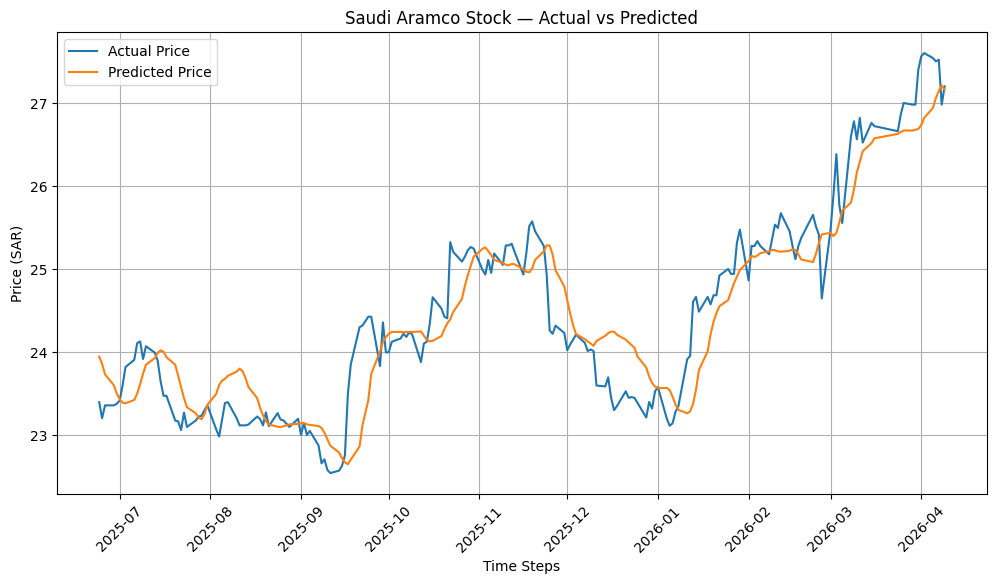

In [ ]:
plt.figure(figsize=(12,6))

dates = data["Date"].iloc[-len(real_inv):].reset_index(drop=True)

plt.plot(dates, real_inv, label="Actual Price")
plt.plot(dates, pred_inv, label="Predicted Price")

plt.title("Saudi Aramco Stock — Actual vs Predicted")
plt.ylabel("Price (SAR)")
plt.xlabel("Time Steps")

plt.legend()
plt.grid()
plt.xticks(rotation=45)

plt.show()

In [ ]:
# REPORT

print(f"\n")
print("AI STOCK REPORT — Saudi ARAMCO 2222")


print("\n REAL DATA")
print(f"- Last Real Price : {last_real:.2f} SAR")
print(f"- Sentiment Avg   : {sent_mean:.3f}")

print("\n PREDICTION DATA")
print(f"- Predicted Price : {last_pred:.2f} SAR")
print(f"- Difference      : {diff:.2f} SAR")
print(f"- Confidence      : {confidence:.1f}%")

print("\n FINAL RECOMMENDATION")
print(f"   >>> {decision} <<<")

print("\n")

print("\n NEWS SOURCES (Latest Articles)")
latest_news = news_df.sort_values("Date", ascending=False).head(5)

for i, row in latest_news.iterrows():
    print("-", row["Link"])



AI STOCK REPORT — Saudi ARAMCO 2222

 REAL DATA
- Last Real Price : 27.23 SAR
- Sentiment Avg   : 0.160

 PREDICTION DATA
- Predicted Price : 27.17 SAR
- Difference      : -0.06 SAR
- Confidence      : 17.7%

 FINAL RECOMMENDATION
   >>> HOLD <<<



 NEWS SOURCES (Latest Articles)
- https://news.google.com/rss/articles/CBMicEFVX3lxTFBsM2xmWTZYdU9oWW5kR25OQi1QdFE4Si1nWWlvZEV5VlVTcFVCNXNLQkd4clpQUzR3V2Z6Tk1QdW50SmxXSElqU1hEa044d0VNT3g2WEVHcmd2bGFPQU12UXZJNGhwTjlrWElYdkk3bUg?oc=5
- https://news.google.com/rss/articles/CBMiWEFVX3lxTFB0RnZKa2I0LXdCQmZlYmNRME1FUmJmaHNCck9ueE5WRU9oaU9Eb3FQVGNwZElwb0p4ZXpSSDVuZ0hHTmdpZlhMb2drMnQ5eV9UZEE5akZVeFY?oc=5
- https://news.google.com/rss/articles/CBMiogFBVV95cUxQMHNWNGJJRktiQ1hkeHhqUjZzaDNEdG5mWEZDa050aUJWVzRMNkw2MnA2TWdxbG9aYkxTM3dlTFpfUmlsbFpWX2dNbGtOeThjeFp4cWRYeWJYREQ3SUt3WHdWLTJqZnJtSUJOWXV0R2lHa19lbnUwSDFmRlJQQ1F0WS14UlAydnFEY0dTN0xBc3RZWV82U3MwMm9vdGwzUXYxRkE?oc=5
- https://news.google.com/rss/articles/CBMiekFVX3lxTE05Mi1OUzFONlhSTVpHSkdFSVNFb

In [ ]:
print("MODEL PERFORMANCE")
print(f"- RMSE  : {rmse:.4f} SAR")
print(f"- MAE   : {mae:.4f} SAR")
print(f"- MAPE  : {mape:.2f}%")

MODEL PERFORMANCE
- RMSE  : 0.4518 SAR
- MAE   : 0.3496 SAR
- MAPE  : 1.43%
